In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from src.dataloader import LoadForecastDataLoader
from src.models.feedforward import FeedForwardForecast

### Load data and validate the data

In [24]:
loader = LoadForecastDataLoader(
    csv_path="Data/synthetic_ireland_national_hourly.csv",
    datetime_col="timestamp_local",
    features=[
        "hour", "day_of_week", "month",
        "mean_wind_speed",
        "wind_capacity_weighted_wind_speed",
        "wind_speed_squared",
        "wind_speed_lag_1h",
        "mean_temperature",
        "temperature_lag_1h",
    ],
    target="wind_generation_mw",
    lookback=1,
    horizon=1,
    expected_frequency="1h",
)

SAVE_DIR = Path("models/generation_feedforward")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = SAVE_DIR / "best_feedforward.pt"

In [25]:
df_all = loader.get_selected_dataframe()
timestamps = pd.to_datetime(df_all[loader.datetime_col], utc=True)
df_all = df_all.loc[
    (timestamps.dt.year >= 2022) & (timestamps.dt.year <= 2024)
].reset_index(drop=True)

df_all.head()

,timestamp_local,hour,day_of_week,month,mean_wind_speed,wind_capacity_weighted_wind_speed,wind_speed_squared,wind_speed_lag_1h,mean_temperature,temperature_lag_1h,wind_generation_mw
0,2022-01-01 00:00:00+00:00,0,5,1,7.94,8.60,73.905,8.48,1.28,1.57,1346.9
1,2022-01-01 01:00:00+00:00,1,5,1,8.22,8.92,79.647,8.60,1.64,1.19,1553.2
2,2022-01-01 02:00:00+00:00,2,5,1,8.11,8.69,75.457,8.92,0.57,1.57,1436.1
3,2022-01-01 03:00:00+00:00,3,5,1,9.80,10.48,109.749,8.69,0.15,0.46,2370.6
4,2022-01-01 04:00:00+00:00,4,5,1,8.76,9.26,85.692,10.48,-0.08,-0.02,1655.3


### Train, validation and test data separation

In [26]:
n = len(df_all)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_all.iloc[:train_end].copy()
val_df = df_all.iloc[train_end:val_end].copy()
test_df = df_all.iloc[val_end:].copy()

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)

train: (18412, 11)
validation: (3946, 11)
test: (3946, 11)


### Data normalization

In [27]:
features = loader.features
target = loader.target

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[features])
target_scaler.fit(train_df[target])

train_features = feature_scaler.transform(train_df[features])
val_features = feature_scaler.transform(val_df[features])
test_features = feature_scaler.transform(test_df[features])

train_target = target_scaler.transform(train_df[target])
val_target = target_scaler.transform(val_df[target])
test_target = target_scaler.transform(test_df[target])

In [28]:
features


['hour',
 'day_of_week',
 'month',
 'mean_wind_speed',
 'wind_capacity_weighted_wind_speed',
 'wind_speed_squared',
 'wind_speed_lag_1h',
 'mean_temperature',
 'temperature_lag_1h']

### Prepare instant feature datasets

In [29]:
train_dataset = TensorDataset(
    torch.tensor(train_features, dtype=torch.float32),
    torch.tensor(train_target, dtype=torch.float32).unsqueeze(-1),
)
val_dataset = TensorDataset(
    torch.tensor(val_features, dtype=torch.float32),
    torch.tensor(val_target, dtype=torch.float32).unsqueeze(-1),
)
test_dataset = TensorDataset(
    torch.tensor(test_features, dtype=torch.float32),
    torch.tensor(test_target, dtype=torch.float32).unsqueeze(-1),
)

### DataLoaders

In [30]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

X, y = next(iter(train_loader))
print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([64, 9])
y: torch.Size([64, 1, 1])


### Feed-forward model

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FeedForwardForecast(
    input_size=len(features),
    hidden_size=128,
    num_layers=2,
    horizon=1,
    dropout=0.2,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)

FeedForwardForecast(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


### Train and validate

In [ ]:
EPOCHS = 20
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(
                    f"  -> Best model saved to: "
                    f"{BEST_MODEL_PATH}"
                )

    print(
        f"Epoch {epoch + 1:03d} | "
        f"Train loss: {train_loss:.5f} | "
        f"Validation loss: {val_loss:.5f}"
    )

Epoch 001 | Train loss: 0.10506 | Validation loss: 0.03167
Epoch 002 | Train loss: 0.04446 | Validation loss: 0.03454
Epoch 003 | Train loss: 0.03782 | Validation loss: 0.02473
Epoch 004 | Train loss: 0.03456 | Validation loss: 0.02154
Epoch 005 | Train loss: 0.03098 | Validation loss: 0.01939
Epoch 006 | Train loss: 0.03062 | Validation loss: 0.01567
Epoch 007 | Train loss: 0.02736 | Validation loss: 0.01938
Epoch 008 | Train loss: 0.02687 | Validation loss: 0.02070
Epoch 009 | Train loss: 0.02570 | Validation loss: 0.01483
Epoch 010 | Train loss: 0.02392 | Validation loss: 0.02064
Epoch 011 | Train loss: 0.02407 | Validation loss: 0.01534
Epoch 012 | Train loss: 0.02377 | Validation loss: 0.01500
Epoch 013 | Train loss: 0.02331 | Validation loss: 0.02242
Epoch 014 | Train loss: 0.02210 | Validation loss: 0.01529
Epoch 015 | Train loss: 0.02174 | Validation loss: 0.01376
Epoch 016 | Train loss: 0.02289 | Validation loss: 0.02016
Epoch 017 | Train loss: 0.02144 | Validation loss: 0.015

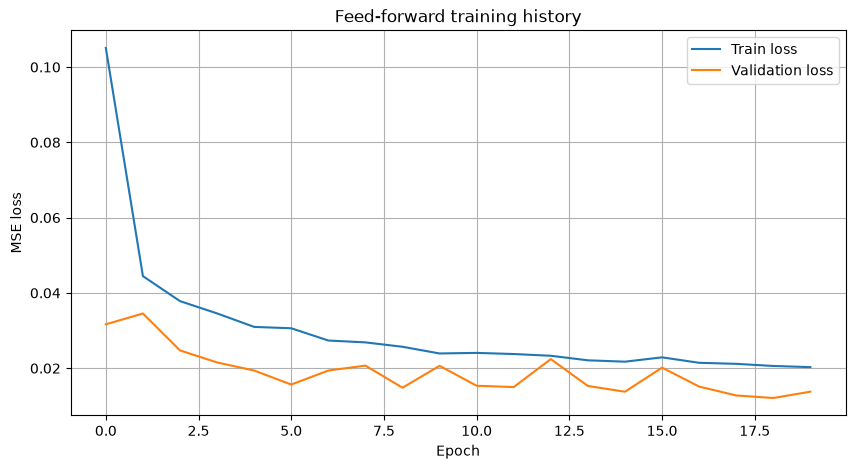

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Feed-forward training history")
plt.legend()
plt.grid(True)
plt.show()

### Test the best model

In [34]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions.append(model(X_batch.to(device)).cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions, axis=0)
actuals = np.concatenate(actuals, axis=0)

predictions_original = target_scaler.inverse_transform(
    predictions.reshape(-1, 1)
).reshape(predictions.shape)
actuals_original = target_scaler.inverse_transform(
    actuals.reshape(-1, 1)
).reshape(actuals.shape)

mae = mean_absolute_error(actuals_original.flatten(), predictions_original.flatten())
rmse = np.sqrt(
    mean_squared_error(actuals_original.flatten(), predictions_original.flatten())
)

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")

MAE:  65.55 MW
RMSE: 102.68 MW


Pred shape: (3946,)
Act shape: (3946,)


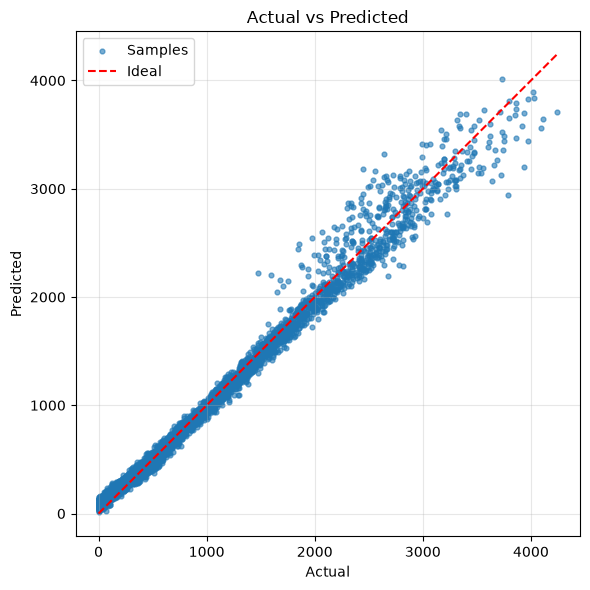

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
results_df = pd.DataFrame({
    "datetime": test_df[loader.datetime_col].reset_index(drop=True),
    "actual": actuals_original.flatten(),
    "predicted": predictions_original.flatten(),
})

results_df.head(20)

,datetime,actual,predicted
0,2024-07-20 14:00:00+00:00,1438.400024,1351.755371
1,2024-07-20 15:00:00+00:00,1861.500000,1845.573730
2,2024-07-20 16:00:00+00:00,2043.099976,2051.334473
3,2024-07-20 17:00:00+00:00,1428.699951,1421.920654
4,2024-07-20 18:00:00+00:00,1014.400024,1031.209106
5,2024-07-20 19:00:00+00:00,1212.500000,1232.470093
6,2024-07-20 20:00:00+00:00,1433.500000,1404.090332
7,2024-07-20 21:00:00+00:00,1109.900024,1080.339722
8,2024-07-20 22:00:00+00:00,1250.199951,1265.631470
9,2024-07-20 23:00:00+00:00,1468.500000,1501.784302


### Visualize the last 24 hours of the test data

In [37]:
# Keep test_df unchanged; create a separate dataframe for visualization.
vis_df = test_df.tail(24).copy()

vis_features = feature_scaler.transform(vis_df[features])
vis_inputs = torch.tensor(vis_features, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    vis_predictions_scaled = model(vis_inputs).cpu().numpy()

vis_predictions = target_scaler.inverse_transform(
    vis_predictions_scaled.reshape(-1, 1)
).ravel()

vis_df["predicted_wind_generation_mw"] = vis_predictions
vis_df[[loader.datetime_col, target[0], "predicted_wind_generation_mw"]]

,timestamp_local,wind_generation_mw,predicted_wind_generation_mw
26280,2024-12-31 00:00:00+00:00,1707.8,1568.532837
26281,2024-12-31 01:00:00+00:00,1869.1,1743.735596
26282,2024-12-31 02:00:00+00:00,1810.6,1743.248779
26283,2024-12-31 03:00:00+00:00,2937.0,2799.712402
26284,2024-12-31 04:00:00+00:00,2837.2,2787.347168
26285,2024-12-31 05:00:00+00:00,3010.4,3024.556152
26286,2024-12-31 06:00:00+00:00,3095.6,3008.848389
26287,2024-12-31 07:00:00+00:00,2666.4,2477.242188
26288,2024-12-31 08:00:00+00:00,1702.5,1649.856201
26289,2024-12-31 09:00:00+00:00,1893.5,1820.354126


In [40]:
vis_df

,timestamp_local,hour,day_of_week,month,mean_wind_speed,wind_capacity_weighted_wind_speed,wind_speed_squared,wind_speed_lag_1h,mean_temperature,temperature_lag_1h,wind_generation_mw,predicted_wind_generation_mw
26280,2024-12-31 00:00:00+00:00,0,1,12,8.52,9.15,83.635,9.00,7.28,7.30,1707.8,1568.532837
26281,2024-12-31 01:00:00+00:00,1,1,12,8.90,9.49,90.127,9.15,7.60,7.20,1869.1,1743.735596
26282,2024-12-31 02:00:00+00:00,2,1,12,9.03,9.48,89.857,9.49,7.68,7.65,1810.6,1743.248779
26283,2024-12-31 03:00:00+00:00,3,1,12,10.62,11.21,125.722,9.48,7.65,7.72,2937.0,2799.712402
26284,2024-12-31 04:00:00+00:00,4,1,12,10.58,11.12,123.721,11.21,7.14,7.68,2837.2,2787.347168
26285,2024-12-31 05:00:00+00:00,5,1,12,10.96,11.46,131.382,11.12,7.46,7.14,3010.4,3024.556152
26286,2024-12-31 06:00:00+00:00,6,1,12,10.91,11.36,128.997,11.46,7.62,7.64,3095.6,3008.848389
26287,2024-12-31 07:00:00+00:00,7,1,12,10.15,10.72,114.878,11.36,7.74,7.75,2666.4,2477.242188
26288,2024-12-31 08:00:00+00:00,8,1,12,8.69,9.27,85.907,10.72,8.39,7.91,1702.5,1649.856201
26289,2024-12-31 09:00:00+00:00,9,1,12,9.03,9.61,92.410,9.27,8.98,8.49,1893.5,1820.354126


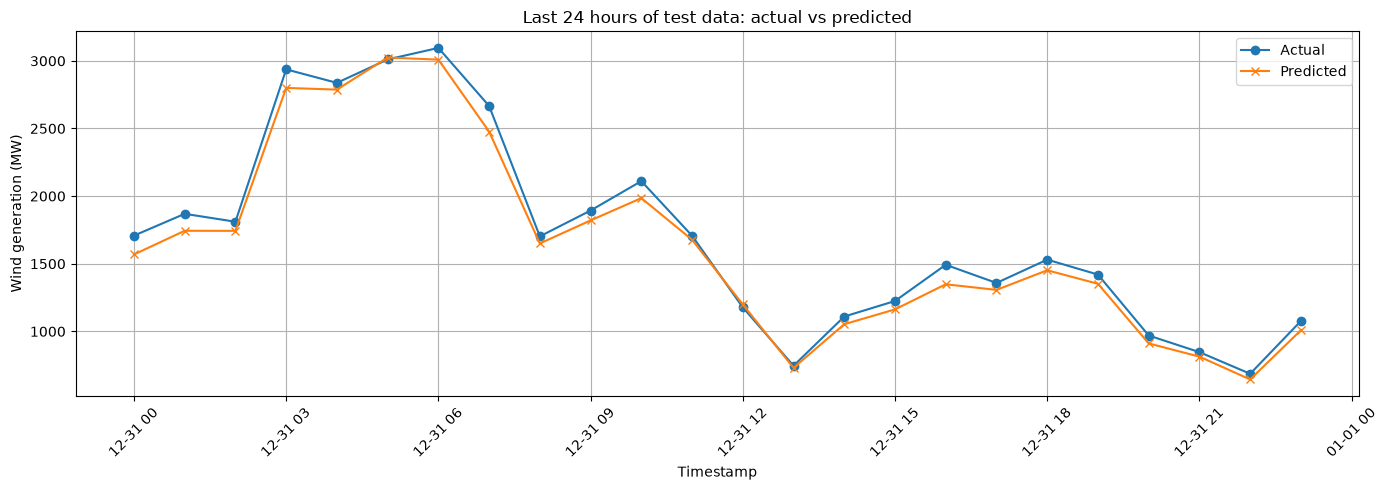

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(
    vis_df[loader.datetime_col],
    vis_df[target[0]],
    marker="o",
    label="Actual",
)
plt.plot(
    vis_df[loader.datetime_col],
    vis_df["predicted_wind_generation_mw"],
    marker="x",
    label="Predicted",
)
plt.title("Last 24 hours of test data: actual vs predicted")
plt.xlabel("Timestamp")
plt.ylabel("Wind generation (MW)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()